In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from useful_func1 import missing_info, out_info
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_auc_score,roc_curve

In [5]:
train_df = pd.read_csv("X_train_clean.csv")
train_df.shape

(40000, 25)

In [6]:
train_df.head()

,age,years_employed,credit_score,credit_history_years,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,loan_amount,interest_rate,debt_to_income_ratio,...,occupation_status_Self-Employed,occupation_status_Student,product_type_Line of Credit,product_type_Personal Loan,loan_intent_Debt Consolidation,loan_intent_Education,loan_intent_Home Improvement,loan_intent_Medical,loan_intent_Personal,loan_status
0,22,2.3,555,0.3,0,1,1,1400,22.45,0.068,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
1,30,1.1,629,7.2,0,0,0,1300,14.40,0.351,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1
2,29,9.7,577,0.6,1,1,1,100000,15.86,0.062,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
3,45,10.0,590,24.6,0,1,0,32600,14.73,0.136,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1
4,32,3.4,693,12.0,0,0,0,25800,17.33,0.017,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1


In [7]:
test_df = pd.read_csv("X_test_clean.csv")
test_df.shape

(10000, 25)

In [8]:
set(train_df.columns) == set(test_df.columns)

True

In [9]:
X_train = train_df.iloc[:, :-1]
y_train = train_df["loan_status"]
X_test = test_df.iloc[:, :-1]
y_test = test_df["loan_status"]
X_train.head()
X_test.head()

,age,years_employed,credit_score,credit_history_years,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,loan_amount,interest_rate,debt_to_income_ratio,...,savings_assets_log,occupation_status_Self-Employed,occupation_status_Student,product_type_Line of Credit,product_type_Personal Loan,loan_intent_Debt Consolidation,loan_intent_Education,loan_intent_Home Improvement,loan_intent_Medical,loan_intent_Personal
0,30,5.7,679,11.0,0,2,0,9600,10.72,0.200,...,9.035749,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,27,4.3,613,1.6,0,0,0,36700,13.55,0.180,...,5.805135,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,21,1.0,590,1.5,0,1,3,60900,21.08,0.400,...,5.451038,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,20,1.2,598,0.5,0,0,1,55300,16.17,0.143,...,2.564949,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,49,20.9,725,8.9,0,0,0,32400,9.68,0.162,...,5.468060,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [10]:
print(f"shape of X_train:- {X_train.shape}")
print(f"shape of X_test:- {X_test.shape}")
print(f"shape of y_train:- {y_train.shape}")
print(f"shape of y_test:- {y_test.shape}")

shape of X_train:- (40000, 24)
shape of X_test:- (10000, 24)
shape of y_train:- (40000,)
shape of y_test:- (10000,)


In [11]:
X_train.describe().T[['mean', 'std']]

,mean,std
age,34.959250,11.133548
years_employed,7.465272,7.640022
credit_score,643.621175,64.703409
credit_history_years,8.175068,7.216927
defaults_on_file,0.054075,0.226168
delinquencies_last_2yrs,0.553800,0.844348
derogatory_marks,0.147725,0.412864
loan_amount,33104.395000,26089.457980
interest_rate,15.520220,4.069850
debt_to_income_ratio,0.285305,0.159631


In [12]:
X_train.dtypes
X_test.dtypes

age                                  int64
years_employed                     float64
credit_score                         int64
credit_history_years               float64
defaults_on_file                     int64
delinquencies_last_2yrs              int64
derogatory_marks                     int64
loan_amount                          int64
interest_rate                      float64
debt_to_income_ratio               float64
loan_to_income_ratio               float64
payment_to_income_ratio            float64
annual_income_log                  float64
current_debt_log                   float64
savings_assets_log                 float64
occupation_status_Self-Employed    float64
occupation_status_Student          float64
product_type_Line of Credit        float64
product_type_Personal Loan         float64
loan_intent_Debt Consolidation     float64
loan_intent_Education              float64
loan_intent_Home Improvement       float64
loan_intent_Medical                float64
loan_intent

In [13]:
print(X_train.shape, X_test.shape)
print(X_train.columns.equals(X_test.columns))
print(y_train.value_counts(normalize=True))


(40000, 24) (10000, 24)
True
loan_status
1    0.5508
0    0.4492
Name: proportion, dtype: float64


In [14]:
## scaling

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [52]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(
    max_iter=5000,
    penalty='l1', 
    solver='liblinear',
    random_state=42
)
model.fit(X_train_scaled, y_train)  



,penalty,'l1'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,5000
,multi_class,'deprecated'


In [55]:
# 3. Predict
y_pred = model.predict(X_test_scaled)

In [56]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [57]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 4))

Accuracy: 0.884


In [58]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[3913  596]
 [ 564 4927]]


In [59]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.87      0.87      4509
           1       0.89      0.90      0.89      5491

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [60]:
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", round(roc_auc, 4))


ROC-AUC: 0.9577


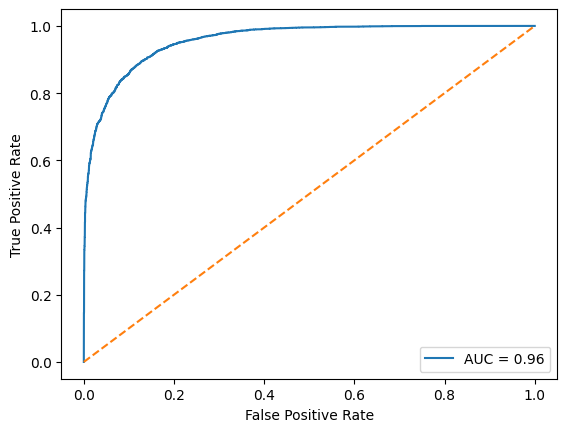

ROC-AUC: 0.9576743637313083


In [61]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

roc_auc = roc_auc_score(y_test, y_prob)
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

print("ROC-AUC:", roc_auc)


In [62]:
X_test_sample = X_test_scaled[:5]
pred_sample = model.predict(X_test_sample)
prob_sample = model.predict_proba(X_test_sample)
print(pred_sample)
print(prob_sample)

[1 1 0 0 1]
[[8.53672922e-02 9.14632708e-01]
 [6.51093785e-02 9.34890622e-01]
 [9.99865944e-01 1.34055665e-04]
 [9.96764487e-01 3.23551262e-03]
 [2.39687360e-03 9.97603126e-01]]


In [63]:
# First 5 samples
actual = y_test[:5].values
predicted = y_pred[:5]

print("Actual:   ", actual)
print("Predicted:", predicted)

Actual:    [1 1 0 0 1]
Predicted: [1 1 0 0 1]


In [64]:
import numpy as np

indices = np.random.choice(len(y_test), 5, replace=False)

print("Actual:   ", y_test.iloc[indices].values)
print("Predicted:", y_pred[indices])

Actual:    [1 0 1 0 1]
Predicted: [1 0 1 0 1]


In [66]:
important = pd.Series(model.coef_[0], index=X_train.columns)
important[important != 0].sort_values(ascending=False)

current_debt_log                   2.782248
loan_intent_Education              1.135412
credit_score                       0.877380
loan_intent_Personal               0.823291
credit_history_years               0.698418
years_employed                     0.375737
loan_intent_Home Improvement       0.343723
loan_intent_Medical                0.338041
savings_assets_log                 0.327408
loan_amount                        0.104114
occupation_status_Student          0.081399
occupation_status_Self-Employed    0.038585
age                                0.012370
loan_to_income_ratio              -0.204067
loan_intent_Debt Consolidation    -0.297831
derogatory_marks                  -0.520834
delinquencies_last_2yrs           -0.847728
payment_to_income_ratio           -0.894014
annual_income_log                 -1.842117
product_type_Personal Loan        -1.934668
interest_rate                     -2.135740
product_type_Line of Credit       -2.171795
defaults_on_file                

In [68]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

# Predictions on train
y_train_pred = model.predict(X_train_scaled)
y_train_prob = model.predict_proba(X_train_scaled)[:,1]

# Predictions on test
y_test_pred = model.predict(X_test_scaled)
y_test_prob = model.predict_proba(X_test_scaled)[:,1]

# Accuracy
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy :", accuracy_score(y_test, y_test_pred))

# F1 Score
print("Train F1:", f1_score(y_train, y_train_pred))
print("Test F1 :", f1_score(y_test, y_test_pred))

# ROC-AUC
print("Train ROC-AUC:", roc_auc_score(y_train, y_train_prob))
print("Test ROC-AUC :", roc_auc_score(y_test, y_test_prob))


Train Accuracy: 0.881125
Test Accuracy : 0.884
Train F1: 0.8929993924255721
Test F1 : 0.894679498819684
Train ROC-AUC: 0.9565197373802923
Test ROC-AUC : 0.9576743637313083


## random Forest

In [24]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=200,       # number of trees
    max_depth=None,         # let trees grow fully
    random_state=42,
    class_weight='balanced' # handle imbalance
)

rf_model.fit(X_train, y_train)


,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
# Predicted class
y_pred = rf_model.predict(X_test)

# Predicted probability for class 1
y_prob = rf_model.predict_proba(X_test)[:, 1]


In [27]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [8, 10, 20],
    'min_samples_split': [5, 7, 10]
}

grid = GridSearchCV(rf_model, param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best ROC-AUC:", grid.best_score_)

Best params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 300}
Best ROC-AUC: 0.9719450104027306


In [28]:
best_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)

# Train the model
best_rf.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,20
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
# Predict classes
y_pred = best_rf.predict(X_test)

# Predict probabilities
y_prob = best_rf.predict_proba(X_test)[:,1]


In [30]:

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", round(acc, 4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)
print("Test ROC-AUC:", round(roc_auc,4))


Test Accuracy: 0.9154
Confusion Matrix:
 [[4070  439]
 [ 407 5084]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.90      0.91      4509
           1       0.92      0.93      0.92      5491

    accuracy                           0.92     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.92      0.92      0.92     10000

Test ROC-AUC: 0.9756


In [31]:
## check overfitting
# Train predictions
y_train_pred = best_rf.predict(X_train)
y_train_prob = best_rf.predict_proba(X_train)[:,1]

train_roc_auc = roc_auc_score(y_train, y_train_prob)
test_roc_auc  = roc_auc_score(y_test, y_prob)

print("Train ROC-AUC:", round(train_roc_auc,4))
print("Test ROC-AUC :", round(test_roc_auc,4))


Train ROC-AUC: 0.9999
Test ROC-AUC : 0.9756


In [32]:
## feature important
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("--- Top 10 Important Features ---")
print(importances.head(10))


--- Top 10 Important Features ---
                    Feature  Importance
2              credit_score    0.232792
8      debt_to_income_ratio    0.178838
9      loan_to_income_ratio    0.072544
7             interest_rate    0.067333
3      credit_history_years    0.067237
5   delinquencies_last_2yrs    0.062828
0                       age    0.043119
1            years_employed    0.040137
11         current_debt_log    0.039352
4          defaults_on_file    0.039233


In [33]:
## test the model
X_test_sample = X_test[:5]  # unscaled, because RF doesn’t need scaling
pred_sample = best_rf.predict(X_test_sample)
prob_sample = best_rf.predict_proba(X_test_sample)

print("Predicted Classes:", pred_sample)
print("Predicted Probabilities:\n", prob_sample)

Predicted Classes: [1 1 0 0 1]
Predicted Probabilities:
 [[0.11771728 0.88228272]
 [0.16296289 0.83703711]
 [0.99518475 0.00481525]
 [0.99499425 0.00500575]
 [0.00431304 0.99568696]]


## XGBoost

In [26]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

print("XGBoost Accuracy:",
      accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 0.9297


In [28]:
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score

# Predictions on train
y_train_pred = xgb_model.predict(X_train)
y_train_prob = xgb_model.predict_proba(X_train)[:,1]

# Predictions on test
y_test_pred = xgb_model.predict(X_test)
y_test_prob = xgb_model.predict_proba(X_test)[:,1]

# Accuracy
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy :", accuracy_score(y_test, y_test_pred))

# F1 Score
print("Train F1:", f1_score(y_train, y_train_pred))
print("Test F1 :", f1_score(y_test, y_test_pred))

# ROC-AUC
print("Train ROC-AUC:", roc_auc_score(y_train, y_train_prob))
print("Test ROC-AUC :", roc_auc_score(y_test, y_test_prob))

print(confusion_matrix(y_test, y_test_pred))
print(classification_report(y_test, y_test_pred))

Train Accuracy: 0.9338
Test Accuracy : 0.9297
Train F1: 0.9404515606728434
Test F1 : 0.9364088647670737
Train ROC-AUC: 0.9863994740043787
Test ROC-AUC : 0.9845725897806765
[[4121  388]
 [ 315 5176]]
              precision    recall  f1-score   support

           0       0.93      0.91      0.92      4509
           1       0.93      0.94      0.94      5491

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



In [30]:
import pandas as pd

# Get feature importance
importance = xgb_model.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feature_importance_df)

                            Feature  Importance
2                      credit_score    0.156599
9              debt_to_income_ratio    0.089846
4                  defaults_on_file    0.078815
5           delinquencies_last_2yrs    0.072426
0                               age    0.061901
19   loan_intent_Debt Consolidation    0.060969
3              credit_history_years    0.051651
11          payment_to_income_ratio    0.049893
23             loan_intent_Personal    0.046037
20            loan_intent_Education    0.041650
10             loan_to_income_ratio    0.039831
8                     interest_rate    0.038934
21     loan_intent_Home Improvement    0.035586
6                  derogatory_marks    0.033492
1                    years_employed    0.030898
22              loan_intent_Medical    0.025953
17      product_type_Line of Credit    0.019264
7                       loan_amount    0.014594
15  occupation_status_Self-Employed    0.011741
16        occupation_status_Student    0

In [32]:
feature_importance_df.head(10)

,Feature,Importance
2,credit_score,0.156599
9,debt_to_income_ratio,0.089846
4,defaults_on_file,0.078815
5,delinquencies_last_2yrs,0.072426
0,age,0.061901
19,loan_intent_Debt Consolidation,0.060969
3,credit_history_years,0.051651
11,payment_to_income_ratio,0.049893
23,loan_intent_Personal,0.046037
20,loan_intent_Education,0.041650


In [35]:
import joblib

# Save model
joblib.dump(xgb_model, "xgb_loan_model.joblib")

# Save feature order
joblib.dump(X_train.columns.tolist(), "feature_order.joblib")

['feature_order.joblib']